# ResNet-18

Here we are training the ResNet-18, trying out how using a pretrained model, data augmentation, regularization and LR scheduler affect the performance.<br>
We picked ResNet-18 for it's smaller size as the dataset is not big enough and we have problem with overfitting.

In [1]:
from helper_functions import build_dataloaders, build_model, train_model, plot_history, evaluate_model

- No pretraining
- No augmentation, regularization
- No LR scheduler

Epoch 1/10 | Train: 44.24% | Val: 38.08% | LR: 0.000100
Epoch 2/10 | Train: 61.63% | Val: 46.61% | LR: 0.000100
Epoch 3/10 | Train: 78.79% | Val: 42.01% | LR: 0.000100
Epoch 4/10 | Train: 91.78% | Val: 48.10% | LR: 0.000100
Epoch 5/10 | Train: 94.65% | Val: 46.48% | LR: 0.000100
Epoch 6/10 | Train: 98.66% | Val: 42.82% | LR: 0.000100
Epoch 7/10 | Train: 97.30% | Val: 45.53% | LR: 0.000100
Epoch 8/10 | Train: 96.47% | Val: 45.66% | LR: 0.000100
Epoch 9/10 | Train: 97.74% | Val: 47.83% | LR: 0.000100
Epoch 10/10 | Train: 93.85% | Val: 46.48% | LR: 0.000100


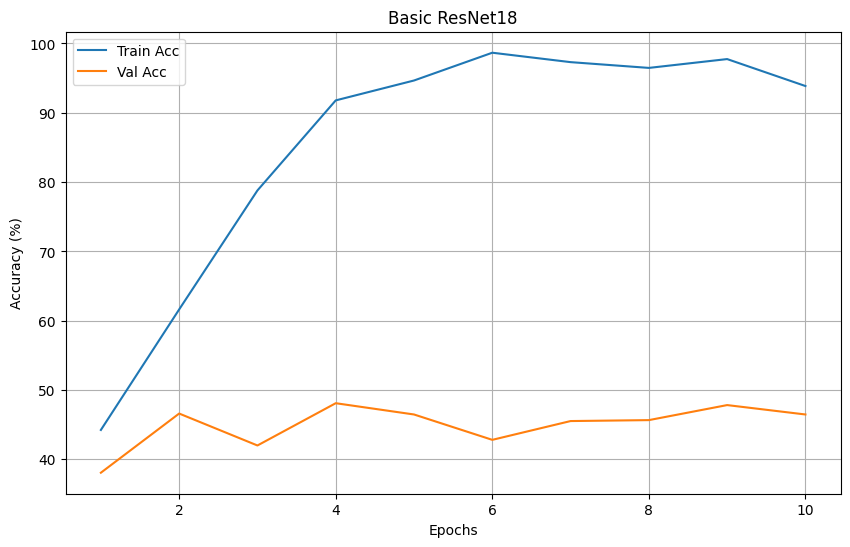


Final Test Accuracy: 46.93%


In [2]:
train_loader, val_loader, test_loader = build_dataloaders(
    "./features/mel_spectrograms",
    use_augmentation=False
)

model, criterion, optimizer, scheduler = build_model(
    model_name="resnet18",
    pretrained=False
)

history = train_model(model, train_loader, val_loader,
                      criterion, optimizer, epochs=10)

plot_history(history, "Basic ResNet18")

test_accuracy = evaluate_model(model, test_loader)

- Using a pretrained model
- No augmentation, regularization
- No LR scheduler

Epoch 1/10 | Train: 44.70% | Val: 44.31% | LR: 0.000100
Epoch 2/10 | Train: 59.97% | Val: 51.22% | LR: 0.000100
Epoch 3/10 | Train: 72.84% | Val: 44.99% | LR: 0.000100
Epoch 4/10 | Train: 83.68% | Val: 48.92% | LR: 0.000100
Epoch 5/10 | Train: 88.88% | Val: 49.73% | LR: 0.000100
Epoch 6/10 | Train: 91.31% | Val: 51.22% | LR: 0.000100
Epoch 7/10 | Train: 93.92% | Val: 50.68% | LR: 0.000100
Epoch 8/10 | Train: 95.21% | Val: 49.05% | LR: 0.000100
Epoch 9/10 | Train: 96.40% | Val: 48.64% | LR: 0.000100
Epoch 10/10 | Train: 98.06% | Val: 50.81% | LR: 0.000100


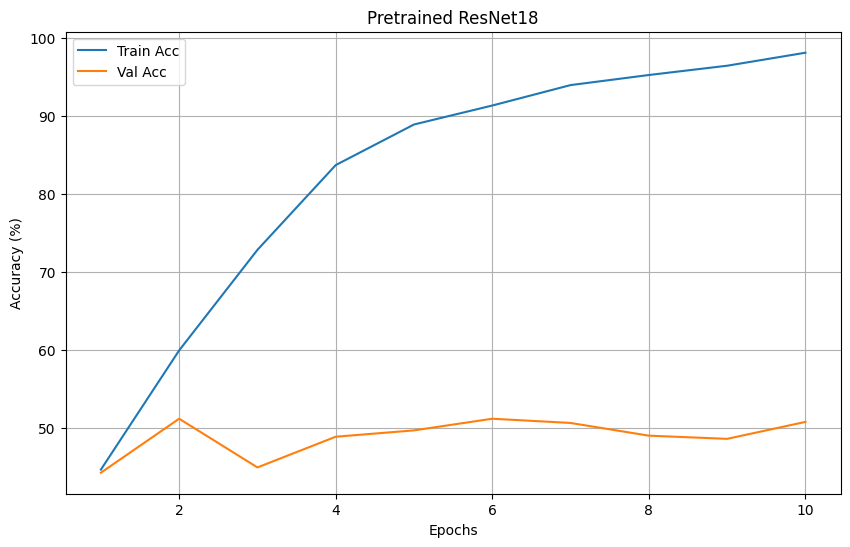


Final Test Accuracy: 54.18%


In [3]:
train_loader, val_loader, test_loader = build_dataloaders(
    "./features/mel_spectrograms",
    use_augmentation=False
)

model, criterion, optimizer, scheduler = build_model(
    model_name="resnet18",
    pretrained=True
)

history = train_model(model, train_loader, val_loader,
                      criterion, optimizer, epochs=10)

plot_history(history, "Pretrained ResNet18")

test_accuracy = evaluate_model(model, test_loader)

- Using a pretrained model
- Using augmentation and regularization
- No LR scheduler

Regularization:
- Data Augmentation (Gaussian nose). TODO: Try pitch etc...
- Frequency and time masking
- Dropout
- Label smoothing
- Weight decay

Epoch 1/20 | Train: 32.17% | Val: 40.92% | LR: 0.000100
Epoch 2/20 | Train: 39.41% | Val: 45.93% | LR: 0.000100
Epoch 3/20 | Train: 43.02% | Val: 47.70% | LR: 0.000100
Epoch 4/20 | Train: 47.33% | Val: 47.43% | LR: 0.000100
Epoch 5/20 | Train: 49.92% | Val: 44.31% | LR: 0.000100
Epoch 6/20 | Train: 52.60% | Val: 50.27% | LR: 0.000100
Epoch 7/20 | Train: 53.94% | Val: 50.95% | LR: 0.000100
Epoch 8/20 | Train: 56.45% | Val: 49.19% | LR: 0.000100
Epoch 9/20 | Train: 58.17% | Val: 50.27% | LR: 0.000100
Epoch 10/20 | Train: 59.20% | Val: 51.36% | LR: 0.000100
Epoch 11/20 | Train: 61.68% | Val: 56.91% | LR: 0.000100
Epoch 12/20 | Train: 63.16% | Val: 53.79% | LR: 0.000100
Epoch 13/20 | Train: 66.88% | Val: 56.50% | LR: 0.000100
Epoch 14/20 | Train: 67.59% | Val: 48.64% | LR: 0.000100
Epoch 15/20 | Train: 69.92% | Val: 50.14% | LR: 0.000100
Epoch 16/20 | Train: 69.64% | Val: 53.52% | LR: 0.000100
Epoch 17/20 | Train: 72.99% | Val: 52.03% | LR: 0.000100
Epoch 18/20 | Train: 75.28% | Val: 52.17

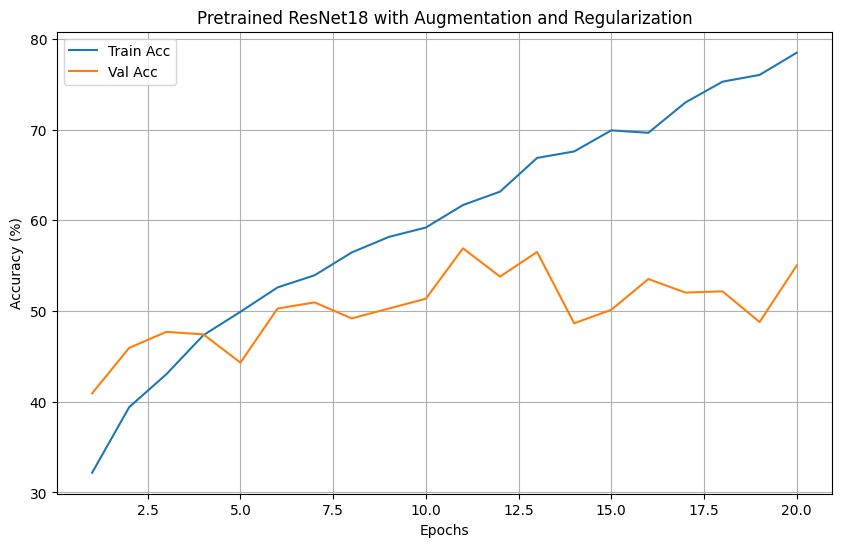


Final Test Accuracy: 59.21%


In [4]:
train_loader, val_loader, test_loader = build_dataloaders(
    "./features/mel_spectrograms",
    use_augmentation=True,
    add_noise_std=0.005,
    freq_mask_param=15,
    time_mask_param=30
)

model, criterion, optimizer, scheduler = build_model(
    model_name="resnet18",
    pretrained=True,
    use_regularization=True,
    dropout_rate=0.5,
    label_smoothing=0.1,
    weight_decay=1e-3
)

history = train_model(model, train_loader, val_loader,
                      criterion, optimizer, epochs=20)

plot_history(history, "Pretrained ResNet18 with Augmentation and Regularization")

test_accuracy = evaluate_model(model, test_loader)

- Using a pretrained model
- Using augmentation and regularization
- Using LR scheduler

Regularization:
- Data Augmentation (Gaussian nose). TODO: Try pitch etc...
- Frequency and time masking
- Dropout
- Label smoothing
- Weight decay

Epoch 1/20 | Train: 31.53% | Val: 40.11% | LR: 0.000100
Epoch 2/20 | Train: 38.83% | Val: 42.55% | LR: 0.000100
Epoch 3/20 | Train: 43.90% | Val: 49.73% | LR: 0.000100
Epoch 4/20 | Train: 46.49% | Val: 49.59% | LR: 0.000100
Epoch 5/20 | Train: 49.95% | Val: 50.81% | LR: 0.000100
Epoch 6/20 | Train: 51.29% | Val: 53.66% | LR: 0.000100
Epoch 7/20 | Train: 54.13% | Val: 52.30% | LR: 0.000100
Epoch 8/20 | Train: 56.57% | Val: 51.36% | LR: 0.000100
Epoch 9/20 | Train: 57.49% | Val: 56.37% | LR: 0.000100
Epoch 10/20 | Train: 59.42% | Val: 55.28% | LR: 0.000100
Epoch 11/20 | Train: 61.87% | Val: 50.00% | LR: 0.000100
Epoch 12/20 | Train: 64.16% | Val: 53.52% | LR: 0.000050
Epoch 13/20 | Train: 68.01% | Val: 56.37% | LR: 0.000050
Epoch 14/20 | Train: 71.05% | Val: 57.99% | LR: 0.000050
Epoch 15/20 | Train: 73.16% | Val: 54.88% | LR: 0.000050
Epoch 16/20 | Train: 74.74% | Val: 54.88% | LR: 0.000050
Epoch 17/20 | Train: 74.50% | Val: 56.37% | LR: 0.000025
Epoch 18/20 | Train: 78.56% | Val: 55.69

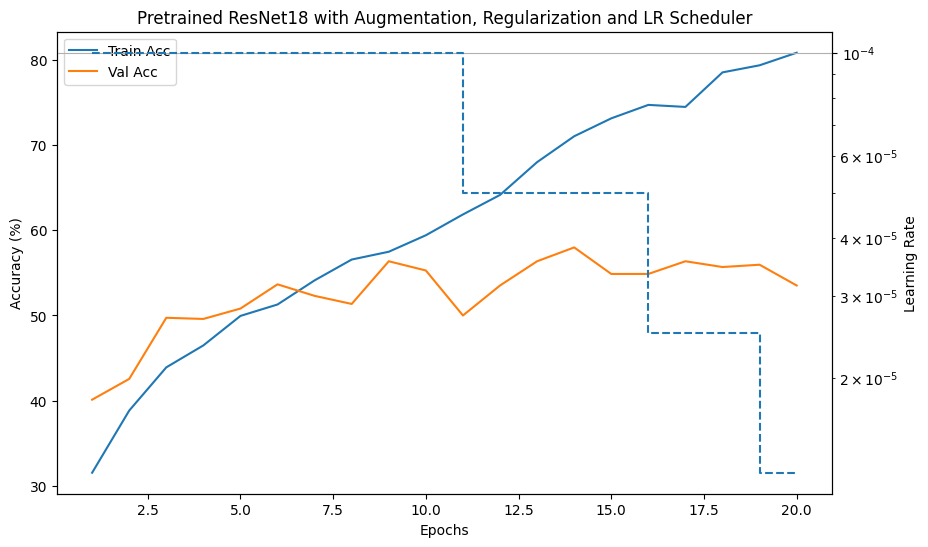


Final Test Accuracy: 61.06%


In [5]:
train_loader, val_loader, test_loader = build_dataloaders(
    "./features/mel_spectrograms",
    use_augmentation=True,
    add_noise_std=0.005,
    freq_mask_param=15,
    time_mask_param=30
)

model, criterion, optimizer, scheduler = build_model(
    model_name="resnet18",
    pretrained=True,
    use_regularization=True,
    dropout_rate=0.5,
    label_smoothing=0.1,
    weight_decay=1e-3,
    use_scheduler=True,
    scheduler_factor=0.5,
    scheduler_patience=2
)

history = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler=scheduler,
    epochs=20
)

plot_history(history, "Pretrained ResNet18 with Augmentation, Regularization and LR Scheduler")

test_accuracy = evaluate_model(model, test_loader)